In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"D:\cse\SEM5\INT234\Project\cleaned_data.csv")
df.head()

,age,gender,job_type,daily_social_media_time,social_platform_preference,number_of_notifications,work_hours_per_day,perceived_productivity_score,actual_productivity_score,stress_level,sleep_hours,screen_time_before_sleep,breaks_during_work,uses_focus_apps,has_digital_wellbeing_enabled,coffee_consumption_per_day,days_feeling_burnout_per_month,weekly_offline_hours,job_satisfaction_score
0,56,Male,Unemployed,4.180940,Facebook,61,6.753558,8.040464,7.291555,4.0,5.116546,0.419102,8,False,False,4,11,21.927072,6.336688
1,46,Male,Health,3.249603,Twitter,59,9.169296,5.063368,5.165093,7.0,5.103897,0.671519,7,True,True,2,25,0.000000,3.412427
2,32,Male,Finance,3.025913,Twitter,57,7.910952,3.861762,3.474053,4.0,8.583222,0.624378,0,True,False,3,17,10.322044,2.474944
3,60,Female,Unemployed,3.025913,Facebook,59,6.355027,2.916331,1.774869,6.0,6.052984,1.204540,1,False,False,0,4,23.876616,1.733670
4,25,Male,IT,3.025913,Telegram,66,6.214096,8.868753,4.951742,7.0,5.405706,1.876254,1,False,True,1,30,10.653519,9.693060


In [3]:
print("Shape:", df.shape)
df.describe()
df.info()

Shape: (30000, 19)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 19 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   age                             30000 non-null  int64  
 1   gender                          30000 non-null  object 
 2   job_type                        30000 non-null  object 
 3   daily_social_media_time         30000 non-null  float64
 4   social_platform_preference      30000 non-null  object 
 5   number_of_notifications         30000 non-null  int64  
 6   work_hours_per_day              30000 non-null  float64
 7   perceived_productivity_score    30000 non-null  float64
 8   actual_productivity_score       30000 non-null  float64
 9   stress_level                    30000 non-null  float64
 10  sleep_hours                     30000 non-null  float64
 11  screen_time_before_sleep        30000 non-null  float64
 12  breaks_during

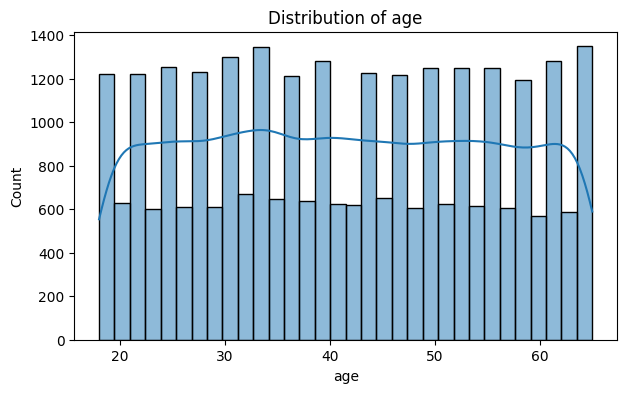

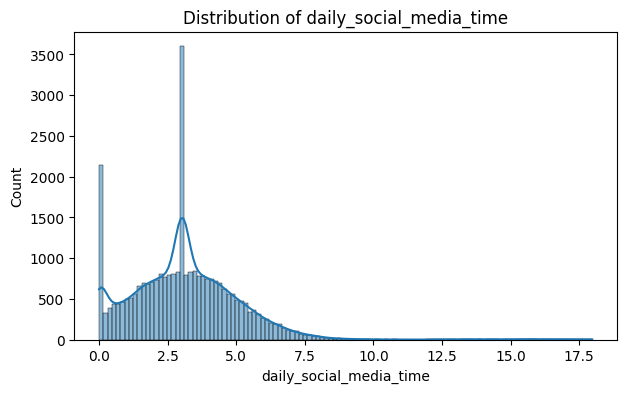

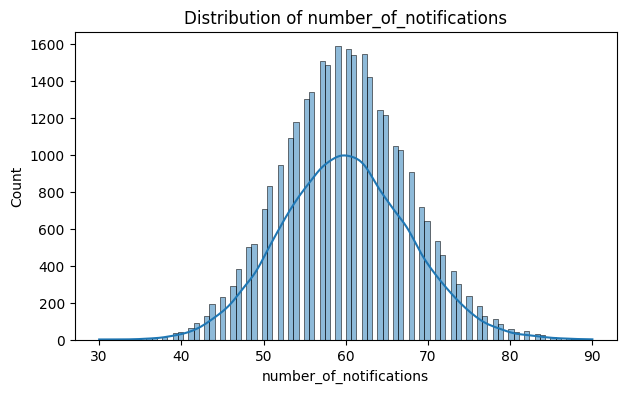

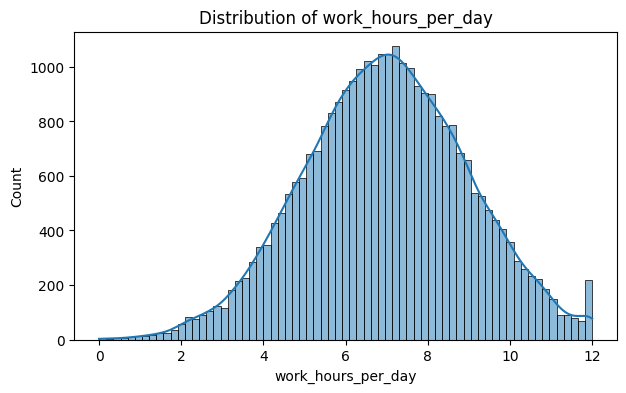

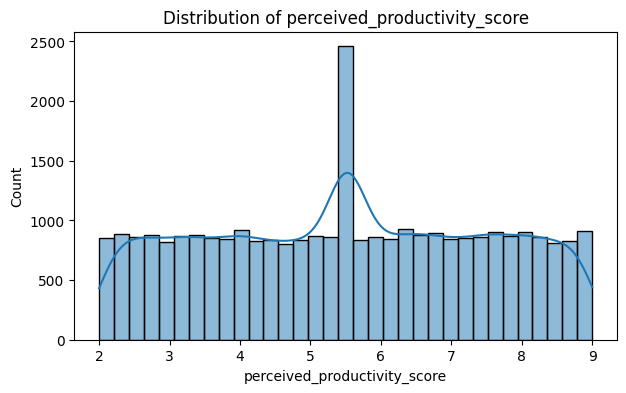

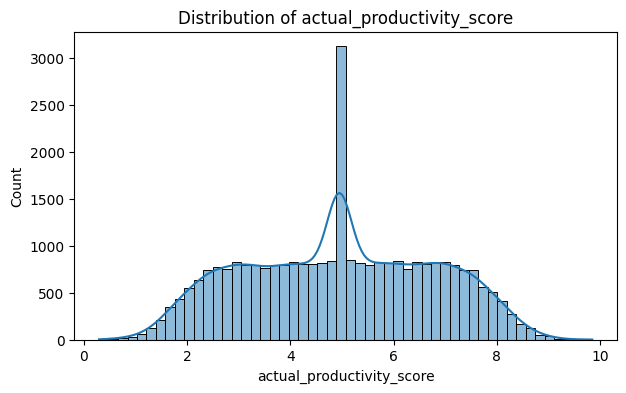

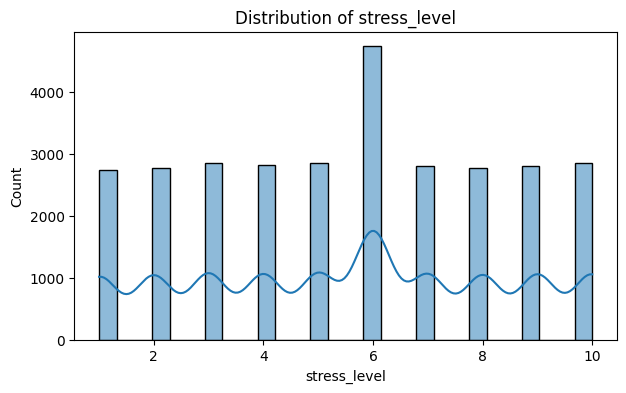

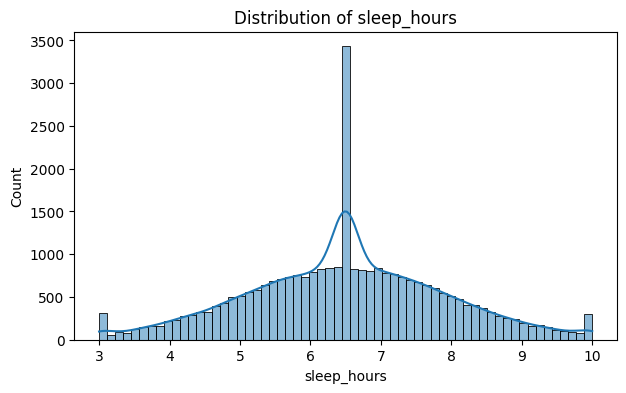

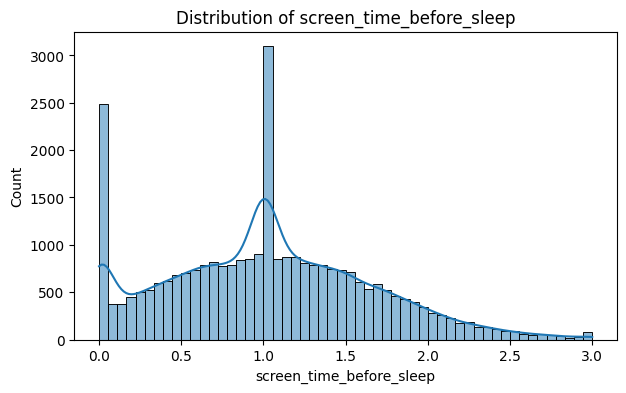

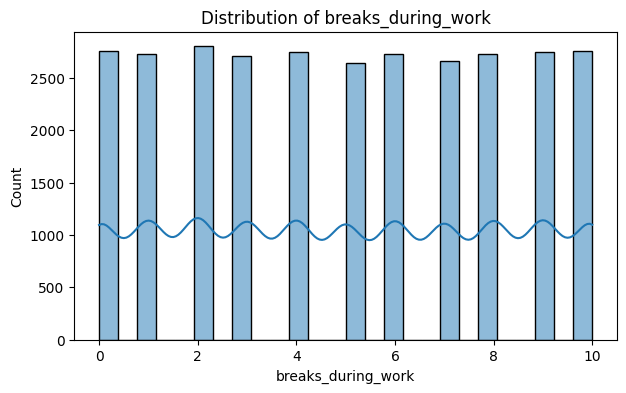

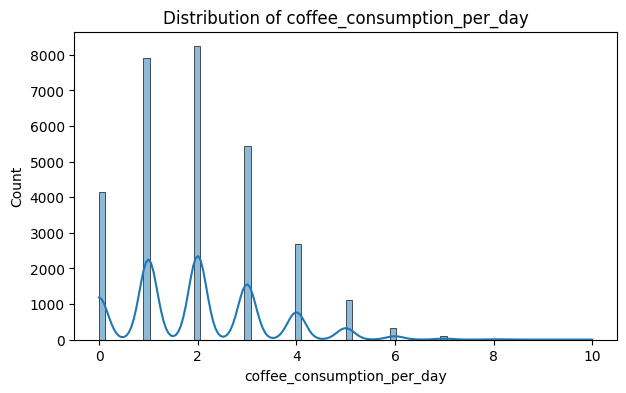

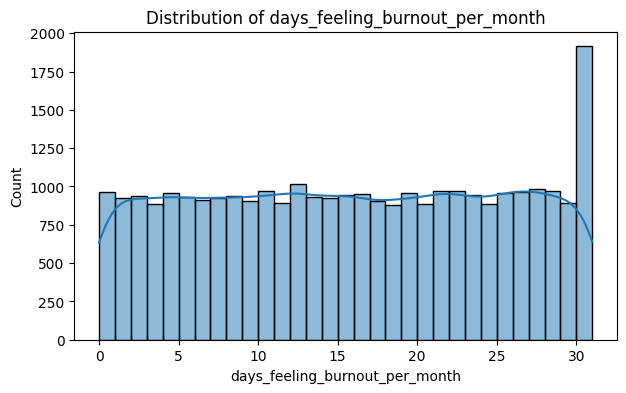

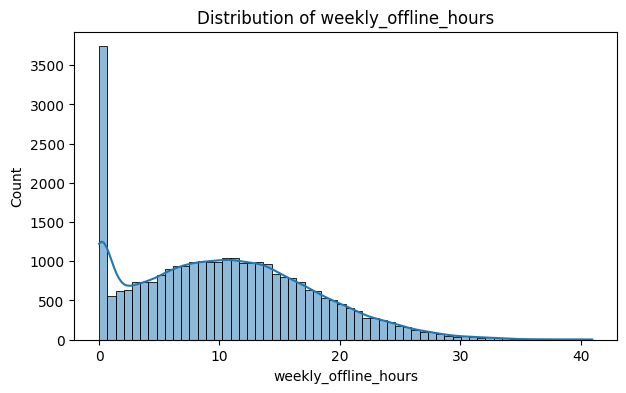

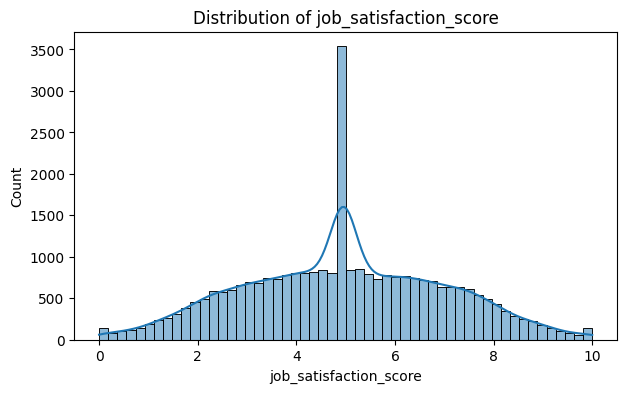

In [4]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns


for col in numeric_cols:
    plt.figure(figsize=(7,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

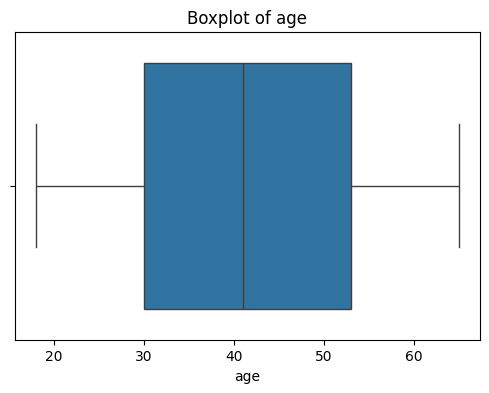

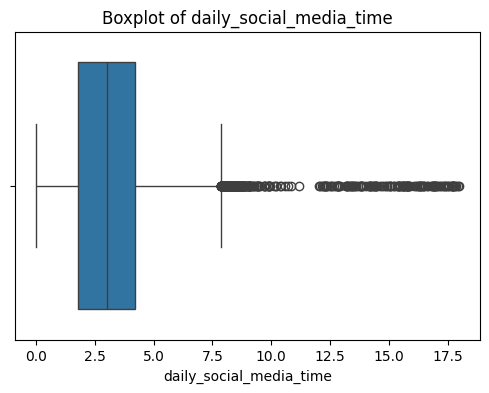

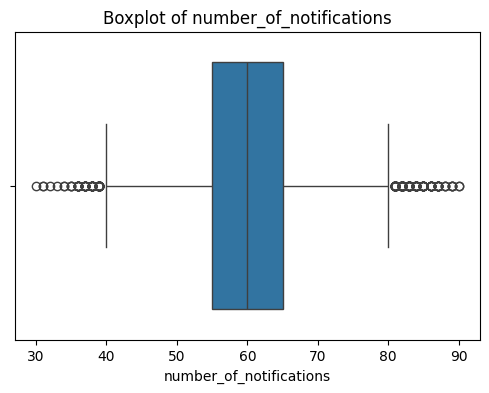

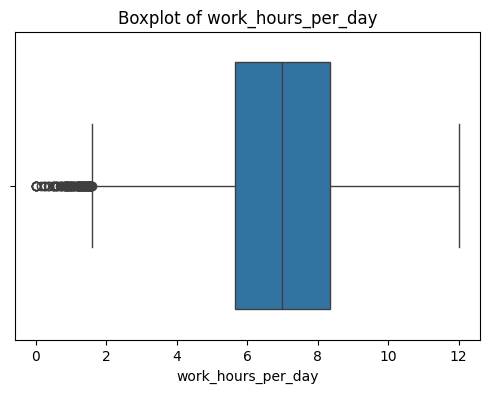

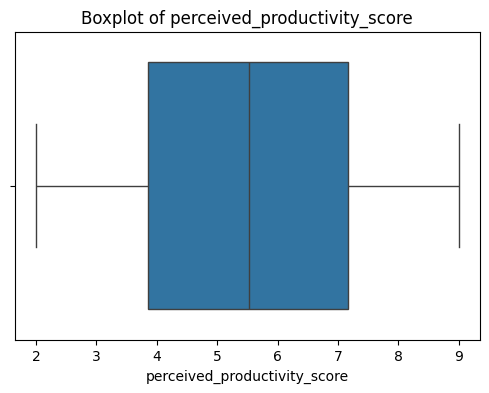

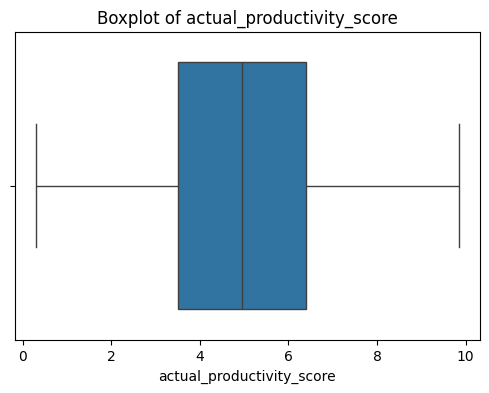

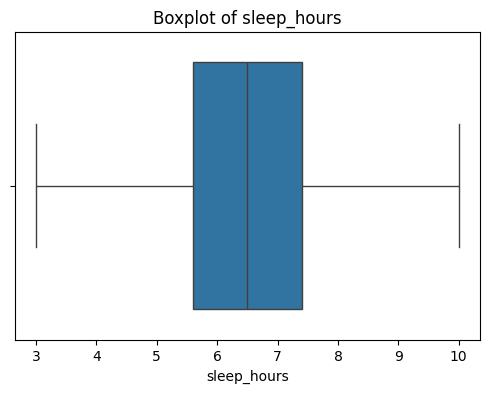

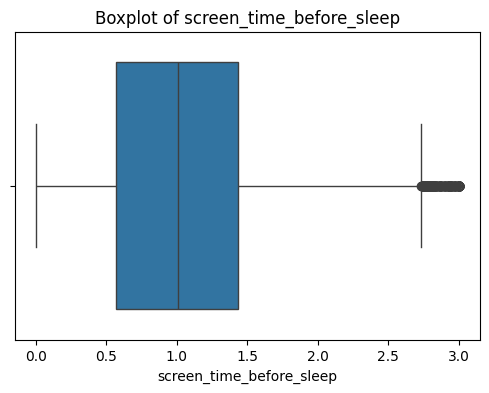

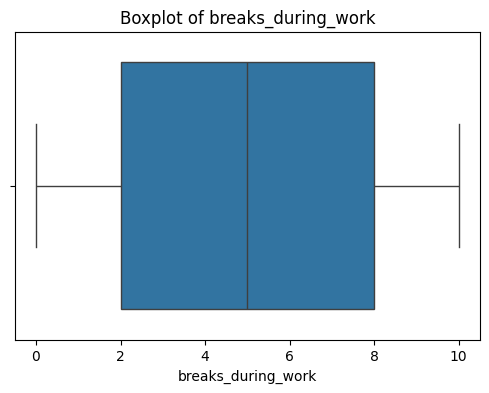

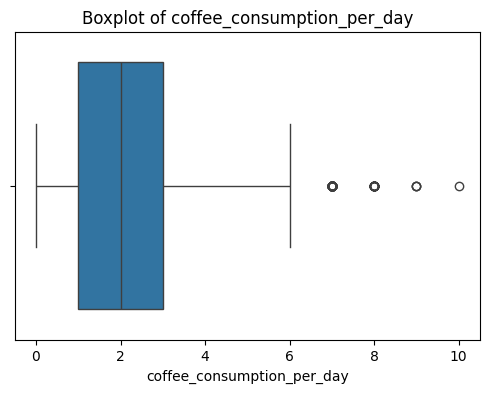

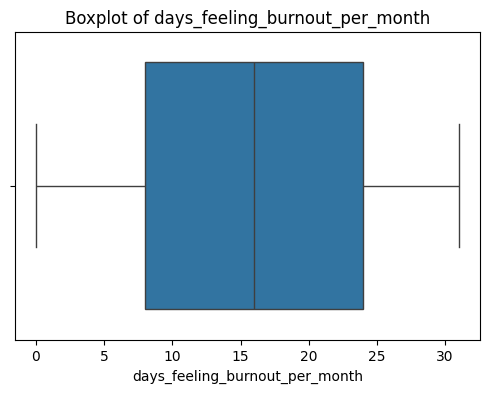

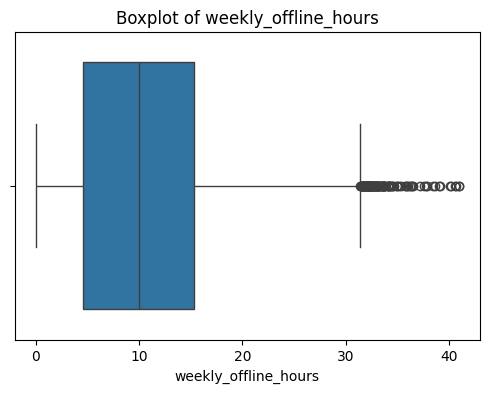

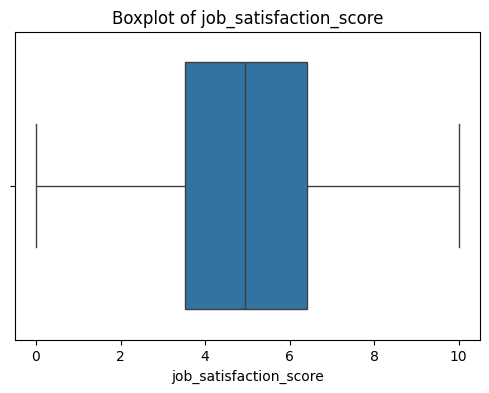

In [5]:
outlier_features = [col for col in numeric_cols if df[col].nunique() > 10]


for col in outlier_features:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

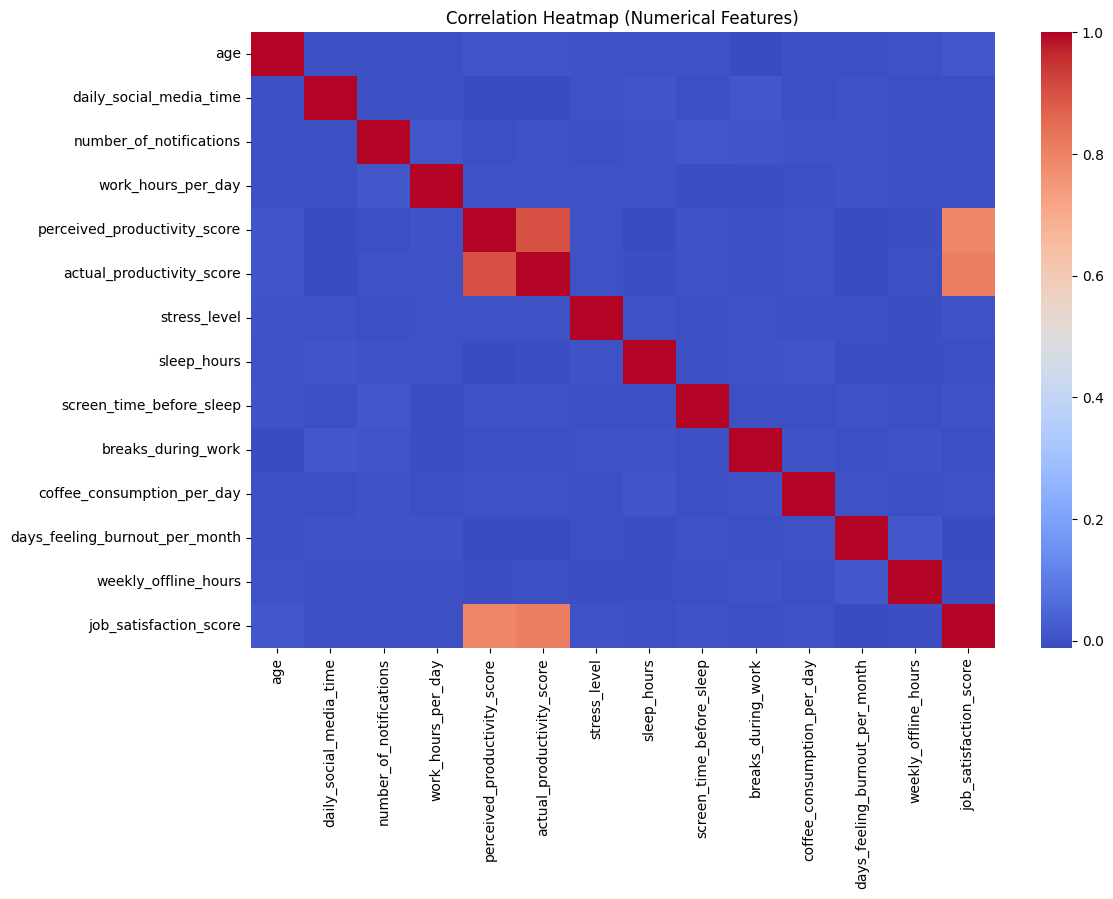

In [6]:
plt.figure(figsize=(12,8))
correlation = df[numeric_cols].corr()
sns.heatmap(correlation, annot=False, cmap="coolwarm")
plt.title("Correlation Heatmap (Numerical Features)")
plt.show()

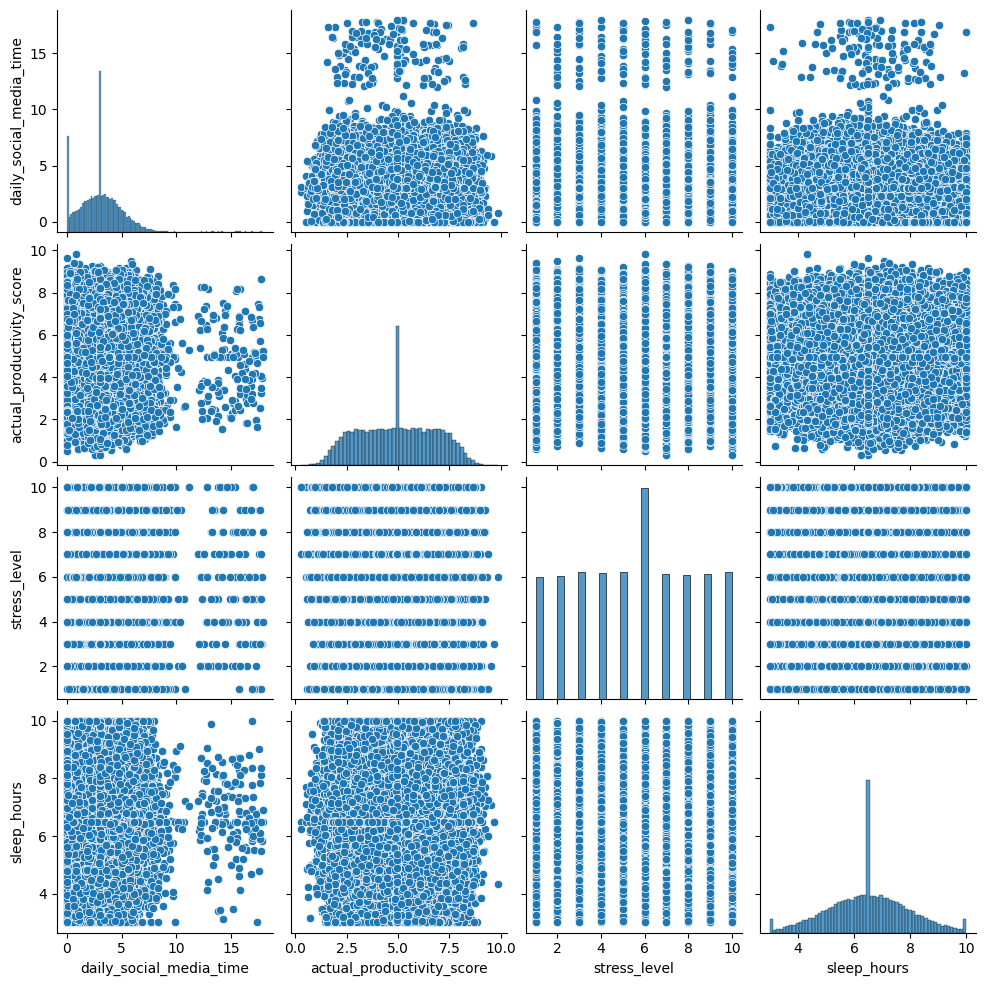

In [7]:
selected = [
    'daily_social_media_time',
    'actual_productivity_score',
    'stress_level',
    'sleep_hours'
]


subset = [col for col in selected if col in df.columns]


if len(subset) > 1:
    sns.pairplot(df[subset])
    plt.show()

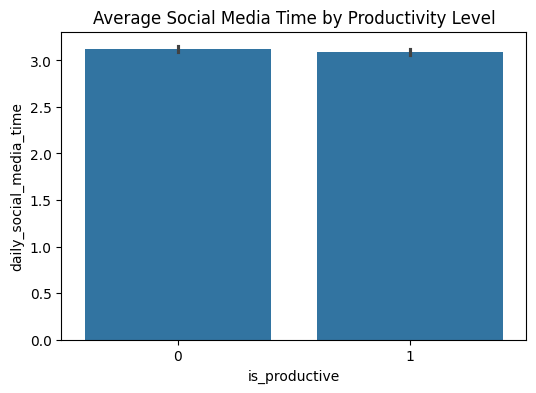

In [8]:
if 'actual_productivity_score' in df.columns:
    df['is_productive'] = (df['actual_productivity_score'] >= df['actual_productivity_score'].median()).astype(int)


    plt.figure(figsize=(6,4))
    sns.barplot(x='is_productive', y='daily_social_media_time', data=df)
    plt.title("Average Social Media Time by Productivity Level")
    plt.show()

In [9]:
#Summary Notes
print("EDA Completed. Insights:")
print("- Distributions plotted for all numeric features")
print("- Outliers inspected using boxplots")
print("- Correlations visualized")
print("- Basic productivity grouping analyzed")

EDA Completed. Insights:
- Distributions plotted for all numeric features
- Outliers inspected using boxplots
- Correlations visualized
- Basic productivity grouping analyzed
